# Seagrass SHAP Model — Consolidated Data Overview

Quick reference view of the key dataframes and figures produced by this pipeline. Column names are human-readable throughout (see the data dictionary below for units and definitions); the underlying pipeline code uses machine-readable snake_case names internally, unaffected by this presentation layer.

In [0]:
import pandas as pd

## Stage 1 — Cleaned DBHYDRO Water Quality

One row per WQ sample event (station x date), after matrix/sampleType filtering, longitude-sign correction, pivoting to wide format, and validation.

**File**: `01_wq_florida_bay_clean.csv`

In [1]:
df = pd.read_csv('01_wq_florida_bay_clean.csv')
df.head()

,Station,Date,Ammonia,Chl-a,DO,NOx,pH,TP,TN,Salinity,Secchi Depth,Turbidity,Water Temperature,Latitude,Longitude
0,C111AC,2016-01-25,0.021,NaN,NaN,0.005,NaN,0.115588,3.537647,17.3,NaN,NaN,15.3,25.17605,-80.792733
1,C111AC,2016-02-10,0.223,NaN,NaN,0.010,NaN,0.078000,3.102857,NaN,NaN,NaN,NaN,25.17605,-80.792733
2,C111AC,2016-03-22,0.031,NaN,NaN,0.005,NaN,0.116200,3.867333,28.0,NaN,NaN,19.2,25.17605,-80.792733
3,C111AC,2016-04-21,1.461,NaN,NaN,0.006,NaN,0.144909,4.126364,NaN,NaN,NaN,NaN,25.17605,-80.792733
4,C111AC,2016-05-26,0.050,NaN,NaN,0.005,NaN,0.123077,3.910000,NaN,NaN,NaN,NaN,25.17605,-80.792733


In [2]:
df.shape

(1742, 15)

In [3]:
df.describe()

,Ammonia,Chl-a,DO,NOx,pH,TP,TN,Salinity,Secchi Depth,Turbidity,Water Temperature,Latitude,Longitude
count,1735.000000,1630.000000,1665.00000,1736.000000,1715.000000,1739.000000,1738.000000,1715.000000,1625.000000,1632.000000,1718.000000,1742.000000,1742.000000
mean,0.064045,2.287694,6.64752,0.010136,8.050787,0.012768,0.910678,29.399175,1.598788,3.446446,26.519412,25.134139,-80.675401
std,0.087896,4.700788,2.44732,0.012610,0.208968,0.023851,0.560725,9.390252,0.704243,5.398930,4.091898,0.089178,0.183870
min,0.005000,0.016000,0.25000,0.005000,7.000000,0.002000,0.156000,0.610000,0.200000,0.200000,11.500000,24.918600,-81.080581
25%,0.019000,0.321250,5.92000,0.005000,8.000000,0.004000,0.584000,24.500000,1.100000,1.000000,24.000000,25.091419,-80.802881
50%,0.040000,0.549000,6.60000,0.005000,8.100000,0.006000,0.780500,31.900000,1.500000,1.800000,27.000000,25.140369,-80.716119
75%,0.075000,1.625000,7.34000,0.009000,8.200000,0.012000,1.060000,36.300000,2.000000,3.600000,29.900000,25.221731,-80.524567
max,1.461000,53.100000,92.50000,0.126000,11.400000,0.467923,6.336154,46.600000,5.500000,81.000000,34.300000,25.240800,-80.388319


## Stage 3 — Water Quality + Spectral Indices Joined

Each WQ record matched to its nearest Sentinel-2 scene (within +/-30 days) with buffered-mean NDAVI/WAVI/NDVI extracted at the station's coordinates.

**File**: `02_wq_spectral_joined.csv`

In [4]:
df = pd.read_csv('02_wq_spectral_joined.csv')
df.head()

,Station,Date,Ammonia,Chl-a,DO,NOx,pH,TP,TN,Salinity,Secchi Depth,Turbidity,Water Temperature,Latitude,Longitude,Matched Scene ID,Matched Scene Date,Cloud Cover,Days Offset,NDAVI,NDAVI Pixel Count,WAVI,WAVI Pixel Count,NDVI,NDVI Pixel Count
0,C111AC,2016-01-25,0.021,NaN,NaN,0.005,NaN,0.115588,3.537647,17.3,NaN,NaN,15.3,25.17605,-80.792733,S2A_MSIL2A_20160102T155642_N0500_R054_T17RNH_20231010T064726,2016-01-02 15:56:42.030,8.37,22.0,0.581809,11,0.444664,11,0.546009,11
1,C111AC,2016-02-10,0.223,NaN,NaN,0.010,NaN,0.078000,3.102857,NaN,NaN,NaN,NaN,25.17605,-80.792733,NaN,NaN,NaN,NaN,NaN,0,NaN,0,NaN,0
2,C111AC,2016-03-22,0.031,NaN,NaN,0.005,NaN,0.116200,3.867333,28.0,NaN,NaN,19.2,25.17605,-80.792733,S2A_MSIL2A_20160401T154922_N0500_R054_T17RNH_20231021T232321,2016-04-01 15:49:22.030,10.03,10.0,0.160345,11,0.145918,11,0.296527,11
3,C111AC,2016-04-21,1.461,NaN,NaN,0.006,NaN,0.144909,4.126364,NaN,NaN,NaN,NaN,25.17605,-80.792733,S2A_MSIL2A_20160401T154922_N0500_R054_T17RNH_20231021T232321,2016-04-01 15:49:22.030,10.03,19.0,0.160345,11,0.145918,11,0.296527,11
4,C111AC,2016-05-26,0.050,NaN,NaN,0.005,NaN,0.123077,3.910000,NaN,NaN,NaN,NaN,25.17605,-80.792733,S2A_MSIL2A_20160521T160522_N0500_R054_T17RNH_20231008T223616,2016-05-21 16:05:22.027,9.63,4.0,0.564991,11,0.453618,11,0.519045,11


In [5]:
df.shape

(1742, 25)

In [6]:
df.describe()

,Ammonia,Chl-a,DO,NOx,pH,TP,TN,Salinity,Secchi Depth,Turbidity,Water Temperature,Latitude,Longitude,Cloud Cover,Days Offset,NDAVI,NDAVI Pixel Count,WAVI,WAVI Pixel Count,NDVI,NDVI Pixel Count
count,1735.000000,1630.000000,1665.00000,1736.000000,1715.000000,1739.000000,1738.000000,1715.000000,1625.000000,1632.000000,1718.000000,1742.000000,1742.000000,1662.000000,1662.000000,1602.000000,1742.000000,1602.000000,1742.000000,1602.000000,1742.000000
mean,0.064045,2.287694,6.64752,0.010136,8.050787,0.012768,0.910678,29.399175,1.598788,3.446446,26.519412,25.134139,-80.675401,6.781234,9.120939,-0.118802,10.343858,-0.062760,10.343858,-0.078254,10.343858
std,0.087896,4.700788,2.44732,0.012610,0.208968,0.023851,0.560725,9.390252,0.704243,5.398930,4.091898,0.089178,0.183870,4.780711,6.721012,0.181235,3.537851,0.123940,3.537851,0.146459,3.537851
min,0.005000,0.016000,0.25000,0.005000,7.000000,0.002000,0.156000,0.610000,0.200000,0.200000,11.500000,24.918600,-81.080581,0.010000,0.000000,-0.571929,0.000000,-0.446107,0.000000,-0.415371,0.000000
25%,0.019000,0.321250,5.92000,0.005000,8.000000,0.004000,0.584000,24.500000,1.100000,1.000000,24.000000,25.091419,-80.802881,3.500000,3.000000,-0.205391,9.000000,-0.112116,9.000000,-0.149728,9.000000
50%,0.040000,0.549000,6.60000,0.005000,8.100000,0.006000,0.780500,31.900000,1.500000,1.800000,27.000000,25.140369,-80.716119,5.970000,8.000000,-0.115123,11.000000,-0.060449,11.000000,-0.091133,11.000000
75%,0.075000,1.625000,7.34000,0.009000,8.200000,0.012000,1.060000,36.300000,2.000000,3.600000,29.900000,25.221731,-80.524567,9.630000,14.000000,-0.065986,12.000000,-0.032644,12.000000,-0.044944,12.000000
max,1.461000,53.100000,92.50000,0.126000,11.400000,0.467923,6.336154,46.600000,5.500000,81.000000,34.300000,25.240800,-80.388319,19.080000,26.000000,0.601700,14.000000,0.483173,14.000000,0.584291,14.000000


## Data Dictionary for the Main Table

One row per column in the table above: description, units, data type, null counts, and summary statistics -- everything needed to interpret the table without access to the pipeline source code.

**File**: `02_wq_spectral_joined_metadata.csv`

In [7]:
df = pd.read_csv('02_wq_spectral_joined_metadata.csv')
df

Column Name,Description,Units,Data Type,Total Rows,Non-Null Count,Null Count,% Null,Unique Values,Min,Max,Mean,Std Dev
Station,"DBHYDRO monitoring station identifier (FLAB*=open bay, C111*=canal inflow)",—,object,1742,1742,0,0.0,22,—,—,—,—
Date,Water quality sample collection date,—,object,1742,1742,0,0.0,376,2016-01-12,2025-12-15,—,—
Ammonia,Ammonia-N; bioavailable nitrogen fraction,mg/L,float64,1742,1735,7,0.4,247,0.005,1.461,0.064,0.0879
Chl-a,Chlorophyll-a; phytoplankton biomass / bloom indicator,µg/L,float64,1742,1630,112,6.4,834,0.016,53.1,2.2877,4.7008
DO,Dissolved oxygen concentration,mg/L,float64,1742,1665,77,4.4,491,0.25,92.5,6.6475,2.4473
NOx,Nitrate+Nitrite-N (NOx); bioavailable nitrogen fraction,mg/L,float64,1742,1736,6,0.3,70,0.005,0.126,0.0101,0.0126
pH,pH (field measurement),—,float64,1742,1715,27,1.5,20,7.0,11.4,8.0508,0.209
TP,"Total phosphorus, reported as elemental P (DBHYDRO: 'Phosphate, Total as P')",mg/L,float64,1742,1739,3,0.2,161,0.002,0.4679,0.0128,0.0239
TN,"Total nitrogen (organic + inorganic, dissolved + particulate)",mg/L,float64,1742,1738,4,0.2,824,0.156,6.3362,0.9107,0.5607
Salinity,Salinity,ppt,float64,1742,1715,27,1.5,408,0.61,46.6,29.3992,9.3903


## 5-Day Resampled Derived Table

Stage 3's output resampled onto a regular 5-day grid per station (linear interpolation). 97% of rows are interpolated, not real measurements -- see Is Observed/Days to Nearest Observation.

**File**: `03_wq_spectral_resampled_5day.csv`

In [8]:
df = pd.read_csv('03_wq_spectral_resampled_5day.csv')
df.head()

,Date,Station,Ammonia,Chl-a,DO,NOx,pH,TP,TN,Salinity,Secchi Depth,Turbidity,Water Temperature,Latitude,Longitude,Is Observed,Days to Nearest Observation,Cloud Cover,Matched Scene ID,Matched Scene Date,Days Offset,NDAVI,NDAVI Pixel Count,WAVI,WAVI Pixel Count,NDVI,NDVI Pixel Count
0,2016-01-25,C111AC,0.021000,NaN,NaN,0.005000,NaN,0.115588,3.537647,17.300000,NaN,NaN,15.300000,25.17605,-80.792733,True,0,8.37,S2A_MSIL2A_20160102T155642_N0500_R054_T17RNH_20231010T064726,2016-01-02 15:56:42.030,22.0,0.581809,11,0.444664,11,0.546009,11
1,2016-01-30,C111AC,0.084125,NaN,NaN,0.006562,NaN,0.103842,3.401775,18.238596,NaN,NaN,15.642105,25.17605,-80.792733,False,5,8.37,S2A_MSIL2A_20160102T155642_N0500_R054_T17RNH_20231010T064726,2016-01-02 15:56:42.030,22.0,0.544839,11,0.418458,11,0.524125,11
2,2016-02-04,C111AC,0.147250,NaN,NaN,0.008125,NaN,0.092096,3.265903,19.177193,NaN,NaN,15.984211,25.17605,-80.792733,False,6,NaN,S2A_MSIL2A_20160102T155642_N0500_R054_T17RNH_20231010T064726,2016-01-02 15:56:42.030,NaN,0.507868,0,0.392252,0,0.502240,0
3,2016-02-09,C111AC,0.210375,NaN,NaN,0.009687,NaN,0.080349,3.130032,20.115789,NaN,NaN,16.326316,25.17605,-80.792733,False,1,NaN,S2A_MSIL2A_20160102T155642_N0500_R054_T17RNH_20231010T064726,2016-01-02 15:56:42.030,NaN,0.470898,0,0.366046,0,0.480356,0
4,2016-02-14,C111AC,0.204268,NaN,NaN,0.009512,NaN,0.081727,3.177440,21.054386,NaN,NaN,16.668421,25.17605,-80.792733,False,4,NaN,S2A_MSIL2A_20160102T155642_N0500_R054_T17RNH_20231010T064726,2016-01-02 15:56:42.030,NaN,0.433927,0,0.339841,0,0.458472,0


In [9]:
df.shape

(13346, 27)

In [10]:
df.describe()

,Ammonia,Chl-a,DO,NOx,pH,TP,TN,Salinity,Secchi Depth,Turbidity,Water Temperature,Latitude,Longitude,Days to Nearest Observation,Cloud Cover,Days Offset,NDAVI,NDAVI Pixel Count,WAVI,WAVI Pixel Count,NDVI,NDVI Pixel Count
count,13346.000000,12704.000000,12922.000000,13346.000000,13255.000000,13346.000000,13346.000000,13346.000000,12704.000000,12704.000000,13346.000000,13346.000000,13346.000000,13346.000000,12743.000000,12743.000000,12720.000000,13346.000000,12720.000000,13346.000000,12720.000000,13346.000000
mean,0.058587,2.475771,6.607428,0.009783,8.052541,0.012801,0.874505,30.111574,1.630650,3.547784,26.620102,25.120148,-80.704578,11.274165,6.854538,8.928431,-0.118105,10.060917,-0.062891,10.060917,-0.078143,10.060917
std,0.076978,4.422261,2.343591,0.011641,0.183864,0.020613,0.530595,9.009106,0.682528,5.103460,3.623438,0.096507,0.192008,7.761294,4.793969,6.640219,0.165677,3.657985,0.112556,3.657985,0.133335,3.657985
min,0.005000,0.024381,0.317143,0.005000,7.003030,0.002000,0.159204,0.620286,0.200000,0.200000,11.500000,24.918600,-81.080581,0.000000,0.010000,0.000000,-0.571929,0.000000,-0.446107,0.000000,-0.415371,0.000000
25%,0.018371,0.358333,5.886062,0.005000,7.960714,0.004346,0.557749,25.580690,1.151613,1.046628,24.145187,25.083700,-80.809219,5.000000,3.500000,3.000000,-0.196866,9.000000,-0.106547,9.000000,-0.143782,9.000000
50%,0.037636,0.678836,6.551099,0.005000,8.057143,0.006888,0.755772,32.800000,1.526491,1.882183,26.953645,25.140369,-80.733683,10.000000,5.970000,8.000000,-0.115558,11.000000,-0.060800,11.000000,-0.085666,11.000000
75%,0.068804,2.224723,7.220634,0.008642,8.173790,0.013429,1.026550,36.644593,2.120000,3.750000,29.665036,25.206681,-80.536581,17.000000,9.750000,13.000000,-0.065865,12.000000,-0.033486,12.000000,-0.043931,12.000000
max,1.365667,48.829302,90.115211,0.122592,11.307500,0.444492,6.179510,46.216393,5.368293,77.282927,34.300000,25.240800,-80.388319,30.000000,19.080000,26.000000,0.601700,14.000000,0.483173,14.000000,0.584291,14.000000


## SEACAR Ground-Truth Spectral Validation

Real Braun-Blanquet seagrass cover scores paired with Sentinel-2 spectral indices extracted at each survey site's own coordinates -- used to validate the spectral pipeline.

**File**: `04_seacar_spectral_validation.csv`

In [11]:
df = pd.read_csv('04_seacar_spectral_validation.csv')
df.head()

,Parameter Name,Braun-Blanquet Score,Date,Location ID,Latitude,Longitude,Species Group,Matched Scene ID,NDAVI,WAVI,NDVI
0,Braun Blanquet Score,4.0,2008-05-17,1066789,25.005750,-80.879960,Total SAV,NaN,NaN,NaN,NaN
1,Braun Blanquet Score,2.0,2013-05-16,1061921,25.153208,-80.408269,Total SAV,NaN,NaN,NaN,NaN
2,Braun Blanquet Score,2.0,2013-05-16,1061922,25.156612,-80.418648,Total SAV,NaN,NaN,NaN,NaN
3,Braun Blanquet Score,2.0,2023-05-29,1278458,25.003306,-80.641389,Total SAV,S2A_MSIL2A_20230515T160511_N0510_R054_T17RNH_20240810T080114,-0.152056,-0.090567,-0.068644
4,Braun Blanquet Score,2.0,2017-05-15,1064361,25.170058,-80.644818,Total SAV,NaN,NaN,NaN,NaN


In [12]:
df.shape

(7139, 11)

In [13]:
df.describe()

,Braun-Blanquet Score,Location ID,Latitude,Longitude,NDAVI,WAVI,NDVI
count,7139.000000,7.139000e+03,7139.000000,7139.000000,3382.000000,3382.000000,3382.000000
mean,2.403502,1.107262e+06,25.103423,-80.689790,-0.150200,-0.091206,-0.105355
std,1.111451,1.091137e+05,0.082387,0.173371,0.115121,0.076722,0.076647
min,0.000000,9.220810e+05,24.938148,-80.949671,-0.560655,-0.466227,-0.498536
25%,2.000000,1.063256e+06,25.037111,-80.818597,-0.231807,-0.140001,-0.145714
50%,2.000000,1.065622e+06,25.108427,-80.690800,-0.122619,-0.069710,-0.094495
75%,3.000000,1.068032e+06,25.174006,-80.585205,-0.069004,-0.037593,-0.054393
max,5.000000,1.341853e+06,25.249933,-80.335010,0.670078,0.549522,0.630478


## Braun-Blanquet Score Reference

What each Braun-Blanquet score (used in the table above) actually represents in terms of taxa abundance and percent cover, plus this project's health-classification mapping.

**File**: `06_braun_blanquet_scale_reference.csv`

In [14]:
df = pd.read_csv('06_braun_blanquet_scale_reference.csv')
df

Score,Modified Score,Description,Project Health Classification
0,0.0,Absent; no individuals present,Not Healthy
N,0.1,"Not many, 1-10 individuals",Not Healthy
T,0.5,Sparsely or very sparsely present; cover very small (less than 5%),Not Healthy
1,1.0,Plentiful but of small cover (less than 5%),Not Healthy
2,2.0,Any number of individuals covering 5-25% of the area,Intermediate
3,3.0,Any number of individuals covering 25-50% of the area,Intermediate
4,4.0,Any number of individuals covering 50-75% of the area,Healthy
5,5.0,Covering more than 75% of the area,Healthy


## SEACAR Nearest-Station WQ Proxy Validation

Compares SEACAR's true co-located water quality readings against the nearest-DBHYDRO-station proxy, to measure the error this spatial approximation introduces.

**File**: `05_seacar_wq_proxy_validation.csv`

In [15]:
df = pd.read_csv('05_seacar_wq_proxy_validation.csv')
df.head()

,Location ID,Nearest Station,Distance to Station (km),Day Offset,Water Temperature (True),Water Temperature (Proxy),Salinity (True),Salinity (Proxy),pH (True),pH (Proxy),DO (True),DO (Proxy),Secchi Depth (True),Secchi Depth (Proxy)
0,922321,FLAB04,3.571028,19,26.88,28.2,27.06,24.9,8.06,8.1,7.09,6.68,NaN,2.8
1,922322,FLAB04,4.432586,19,26.83,28.2,27.56,24.9,8.13,8.1,7.09,6.68,NaN,2.8
2,922323,FLAB04,5.499749,19,26.93,28.2,27.75,24.9,8.13,8.1,7.21,6.68,NaN,2.8
3,922332,FLAB04,2.930242,19,26.80,28.2,26.70,24.9,8.00,8.1,7.09,6.68,NaN,2.8
4,922334,FLAB04,3.499784,19,27.11,28.2,27.12,24.9,8.12,8.1,8.01,6.68,2.9,2.8


In [16]:
df.shape

(2822, 14)

In [17]:
df.describe()

,Location ID,Distance to Station (km),Day Offset,Water Temperature (True),Water Temperature (Proxy),Salinity (True),Salinity (Proxy),pH (True),pH (Proxy),DO (True),DO (Proxy),Secchi Depth (True),Secchi Depth (Proxy)
count,2.822000e+03,2822.000000,2822.000000,2805.000000,2819.000000,2805.000000,2819.000000,2805.000000,2819.000000,2787.000000,2817.000000,513.000000,2817.000000
mean,1.172079e+06,3.743351,13.088944,29.036332,28.128556,35.009968,34.621036,8.169369,8.123590,6.417370,6.275744,1.140097,1.721335
std,1.308040e+05,1.907089,9.263267,1.786100,2.140693,5.916922,6.405123,0.206096,0.178911,1.528756,0.778026,0.540587,0.724855
min,9.223210e+05,0.050690,0.000000,24.100000,24.100000,10.030000,12.300000,7.400000,7.300000,1.960000,3.160000,0.280000,0.400000
25%,1.064440e+06,2.265092,6.000000,27.960000,25.600000,32.920000,31.400000,8.040000,8.000000,5.720000,5.920000,0.750000,1.300000
50%,1.068130e+06,3.459434,11.000000,29.200000,28.700000,36.320000,35.700000,8.150000,8.100000,6.240000,6.320000,1.000000,1.600000
75%,1.306024e+06,5.166046,20.000000,30.300000,30.100000,38.990000,39.300000,8.270000,8.200000,6.950000,6.680000,1.400000,2.100000
max,1.341853e+06,8.218595,30.000000,34.500000,31.400000,46.390000,45.100000,9.330000,8.700000,18.540000,8.900000,3.000000,4.700000


## FWC/NOAA HABSOS Harmful Algal Bloom Data

Karenia brevis (red tide) cell counts in the Florida Bay bbox/study period, each observation assigned to its nearest DBHYDRO station (no fixed HABSOS station network exists) and aggregated to one row per station-date. Cell count is heavily zero-inflated (median 0, occasional bloom spikes up to 103,000 cells/L).

**File**: `07_hab_florida_bay.csv`

In [18]:
df = pd.read_csv('07_hab_florida_bay.csv')
df.head()

,Station,Date,Cell Count,Salinity,Water Temperature,Distance to Station (km),Number of Observations,Category
0,C111AC,2018-04-11,0,40.00,30.00,1.918654,1,not observed
1,C111AC,2018-05-10,0,24.00,30.00,7.204502,1,not observed
2,C111MC,2019-11-12,0,31.99,24.33,1.502110,1,not observed
3,FLAB04,2016-03-17,0,40.00,26.10,13.763096,1,not observed
4,FLAB04,2017-10-16,0,NaN,NaN,2.238778,2,not observed


In [19]:
df.shape

(318, 8)

In [20]:
df.describe()

,Cell Count,Salinity,Water Temperature,Distance to Station (km),Number of Observations
count,318.000000,148.000000,173.000000,318.000000,318.000000
mean,370.018868,34.447248,26.212741,8.462896,1.852201
std,5797.045498,5.516385,3.286328,5.489745,1.131780
min,0.000000,2.200000,17.283333,0.743698,1.000000
25%,0.000000,33.136500,24.330000,3.868621,1.000000
50%,0.000000,35.805000,26.110000,6.872396,1.000000
75%,0.000000,37.040000,28.380000,13.179235,2.000000
max,103000.000000,43.500000,35.000000,23.082697,6.000000


## HAB Data Resampled to a 5-Day Grid

Same 5-day spacing as the main resampled table, but with a tighter 14-day (not 30-day) carry-forward window -- bloom dynamics shift faster than the timescale that justifies 30 days for water quality. Cell Count is carried forward from the nearest real observation (NOT linearly interpolated); Salinity/Water Temperature ARE interpolated.

**File**: `08_hab_resampled_5day.csv`

In [21]:
df = pd.read_csv('08_hab_resampled_5day.csv')
df.head()

,Date,Station,Cell Count,Salinity,Water Temperature,Distance to Station (km),Number of Observations,Category,Is Observed,Days to Nearest Observation
0,2018-04-11,C111AC,0,40.000000,30.0,1.918654,1,not observed,True,0
1,2018-04-16,C111AC,0,37.241379,30.0,1.918654,1,not observed,False,5
2,2018-04-21,C111AC,0,34.482759,30.0,1.918654,1,not observed,False,10
3,2018-04-26,C111AC,0,31.724138,30.0,7.204502,1,not observed,False,14
4,2018-05-01,C111AC,0,28.965517,30.0,7.204502,1,not observed,False,9


In [22]:
df.shape

(1248, 10)

In [23]:
df.describe()

,Cell Count,Salinity,Water Temperature,Distance to Station (km),Number of Observations,Days to Nearest Observation
count,1248.000000,838.000000,1017.000000,1248.000000,1248.000000,1248.000000
mean,206.461538,33.504816,26.125808,8.477606,1.848558,6.192308
std,4146.178279,8.515943,2.737795,5.418106,1.114308,4.134065
min,0.000000,2.240738,17.283333,0.743698,1.000000,0.000000
25%,0.000000,33.101692,24.466667,4.194074,1.000000,3.000000
50%,0.000000,35.696971,25.947053,6.872396,1.000000,6.000000
75%,0.000000,37.599485,27.962162,13.171382,2.000000,10.000000
max,103000.000000,43.477179,34.333333,23.082697,6.000000,14.000000


## Figures

### Water Quality and Spectral Index Time Series (monthly means)
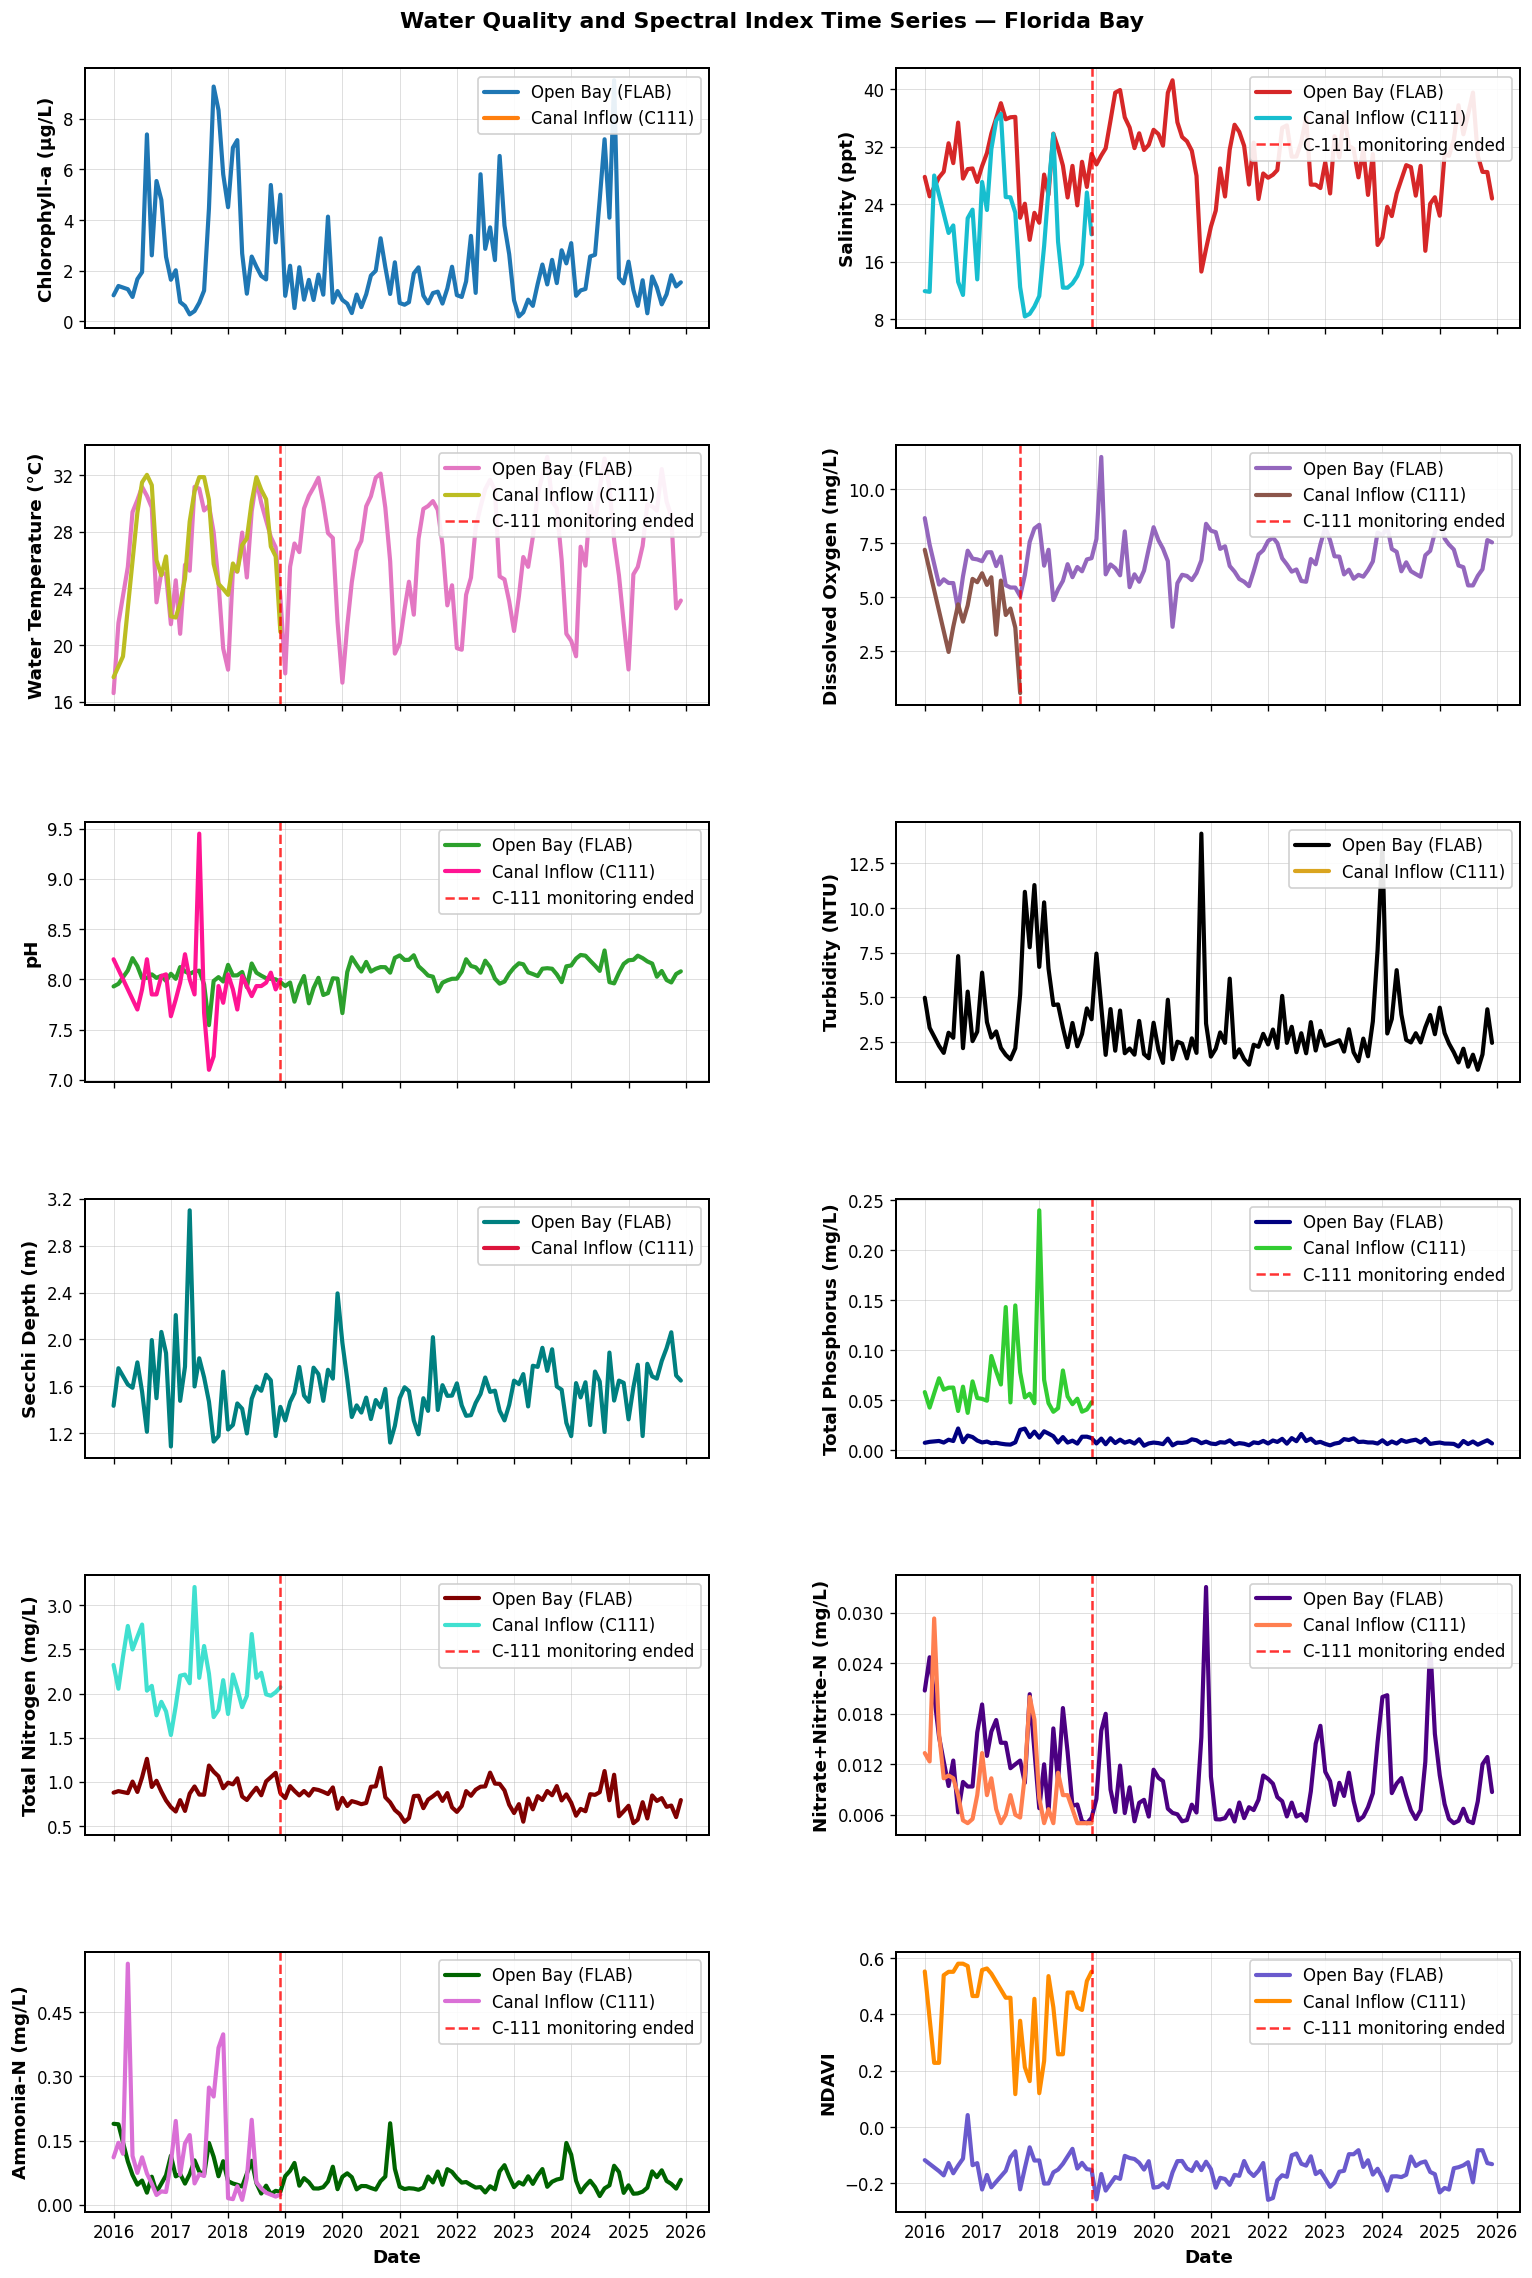

### Water Quality and Spectral Index Raw Samples (scatter)
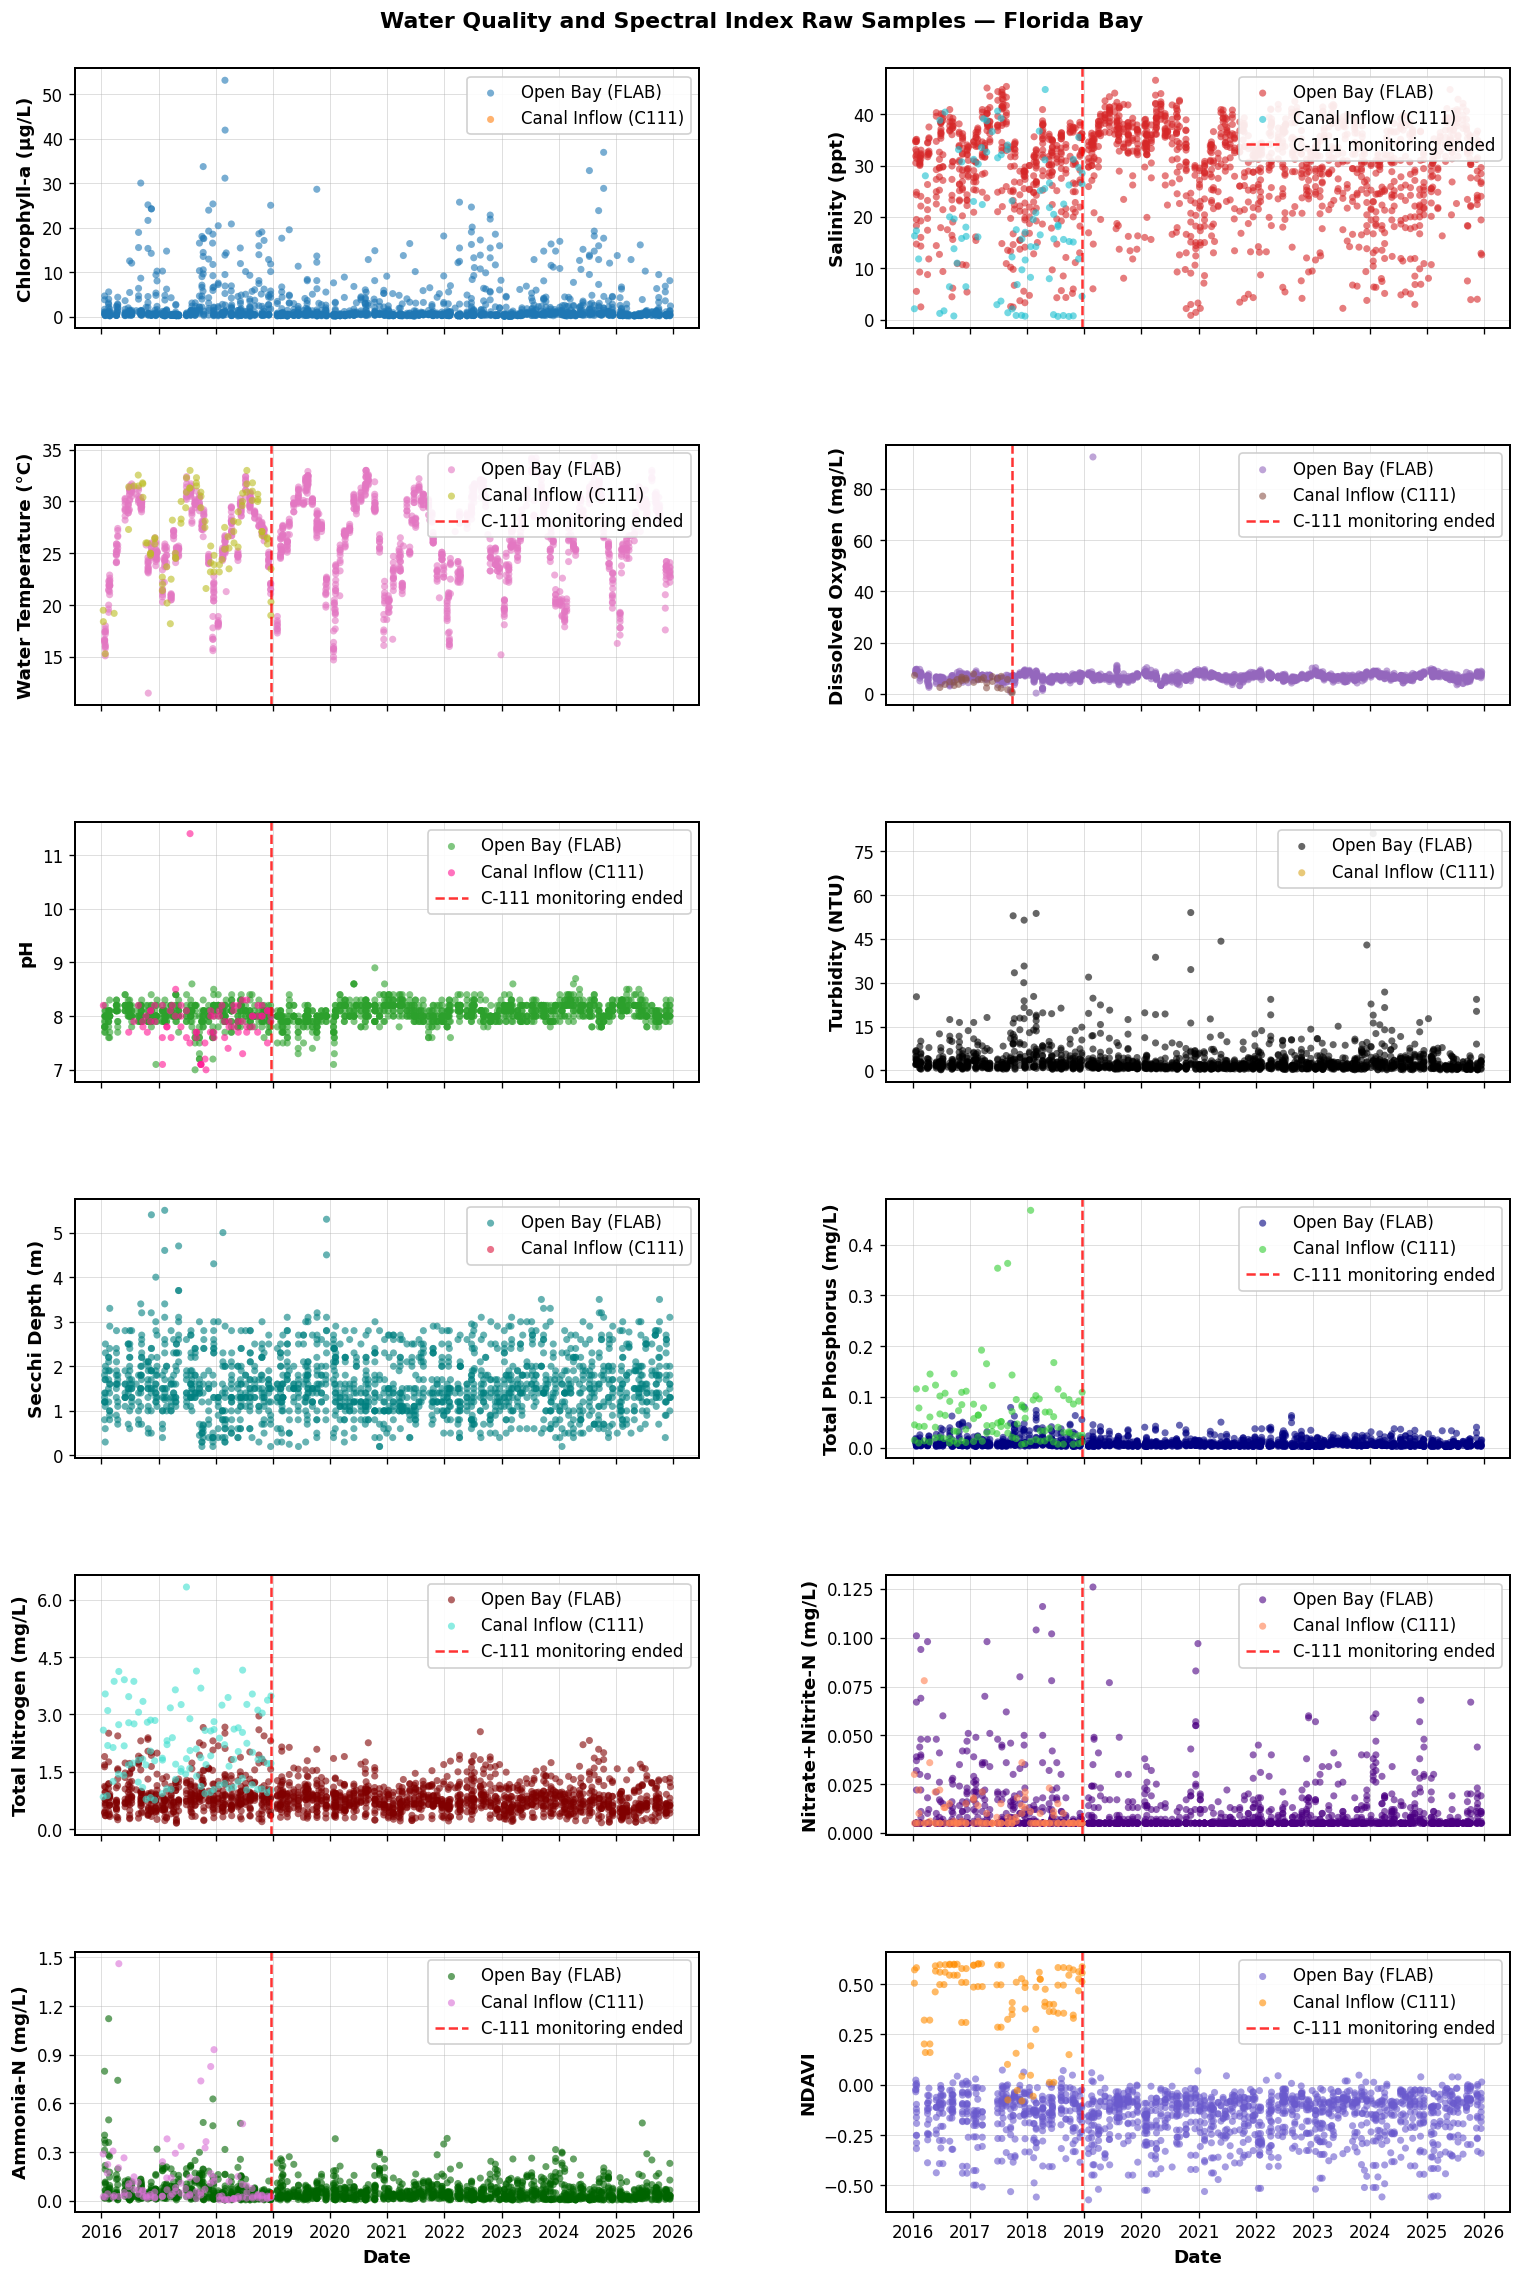

### DBHYDRO Water Quality Monitoring Station Locations
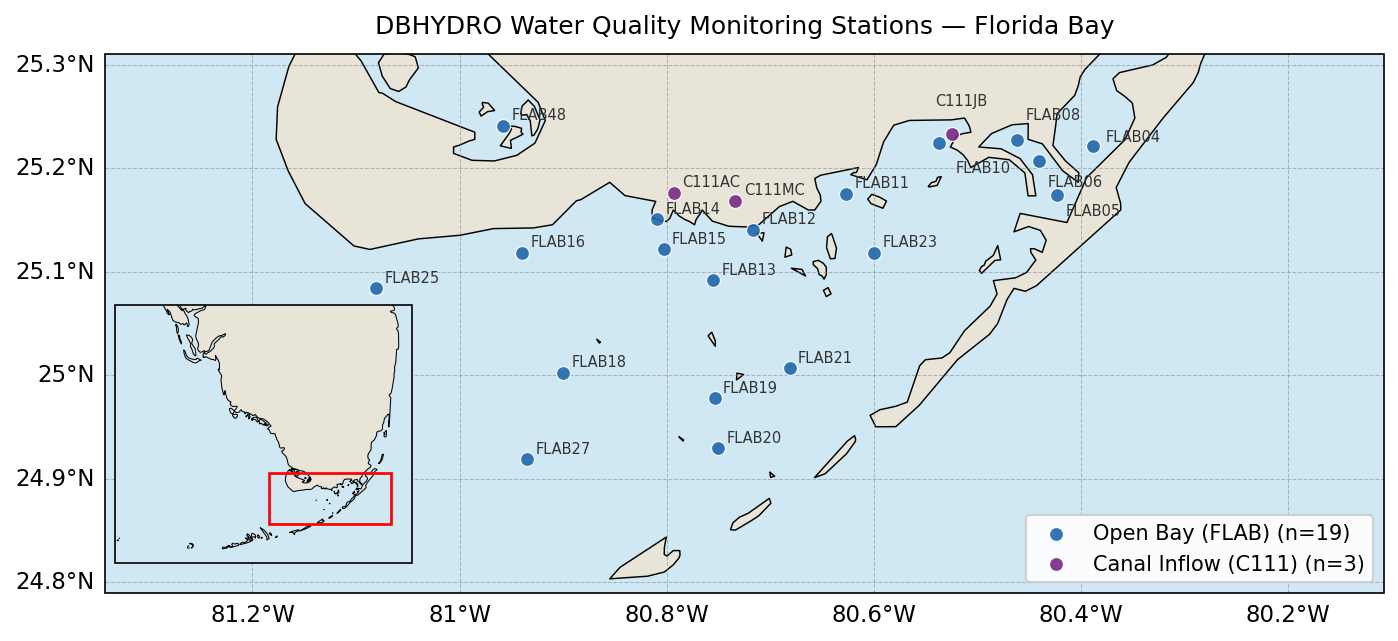

### Sentinel-2 Tile Coverage vs. Study Area
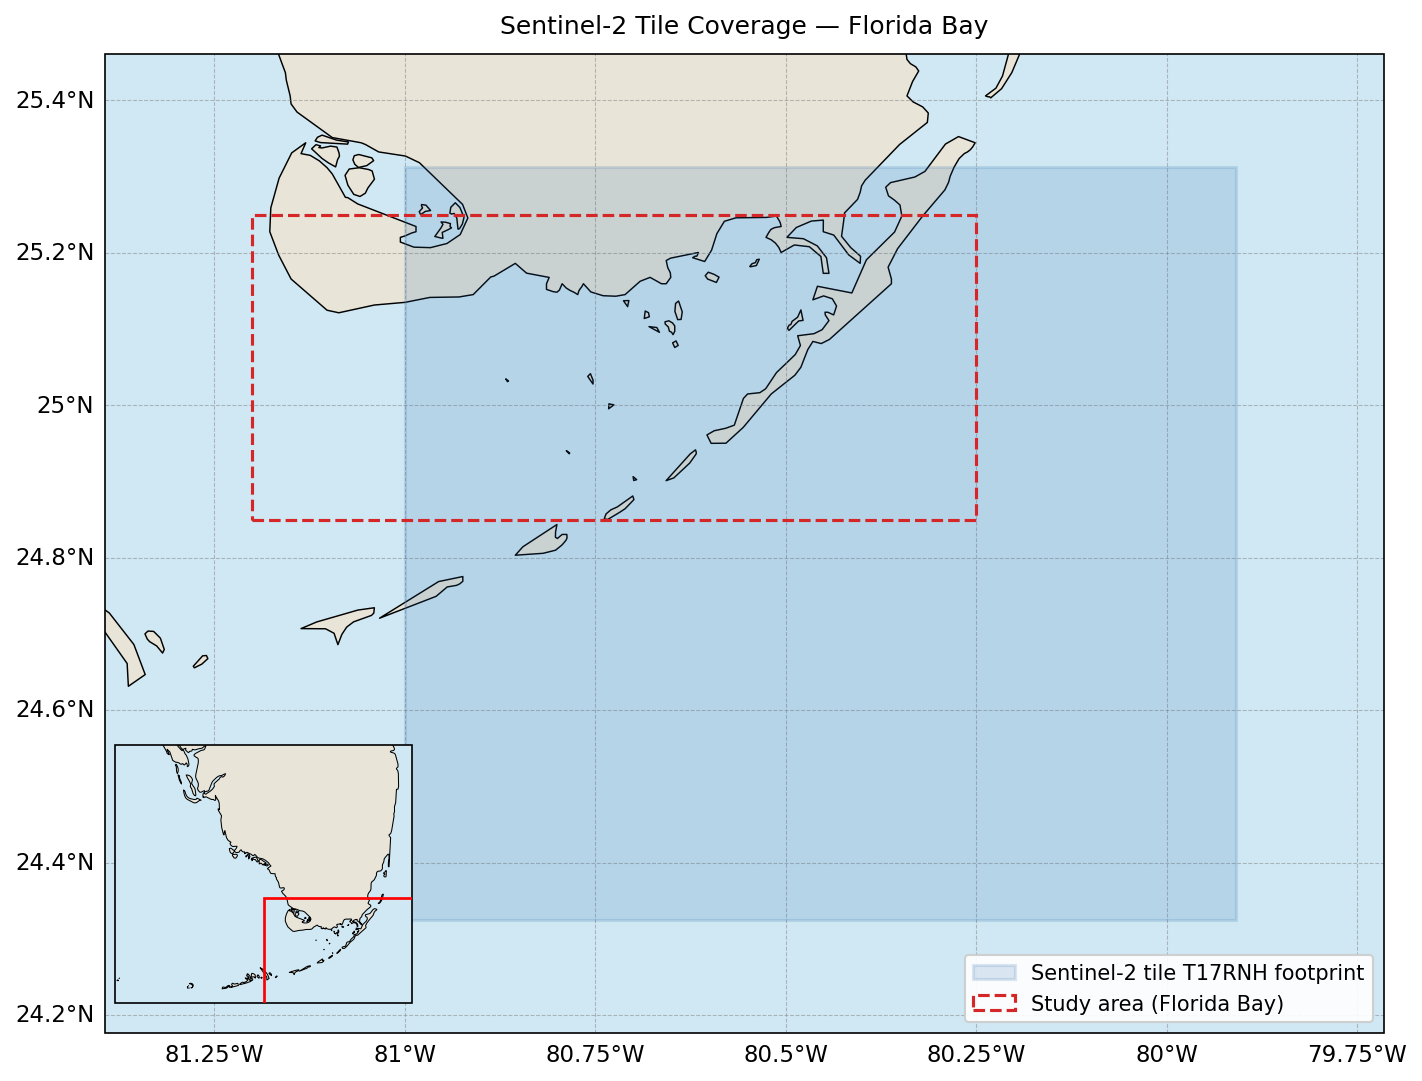

### SEACAR Ground-Truth Sampling Locations (Satellite Basemap)
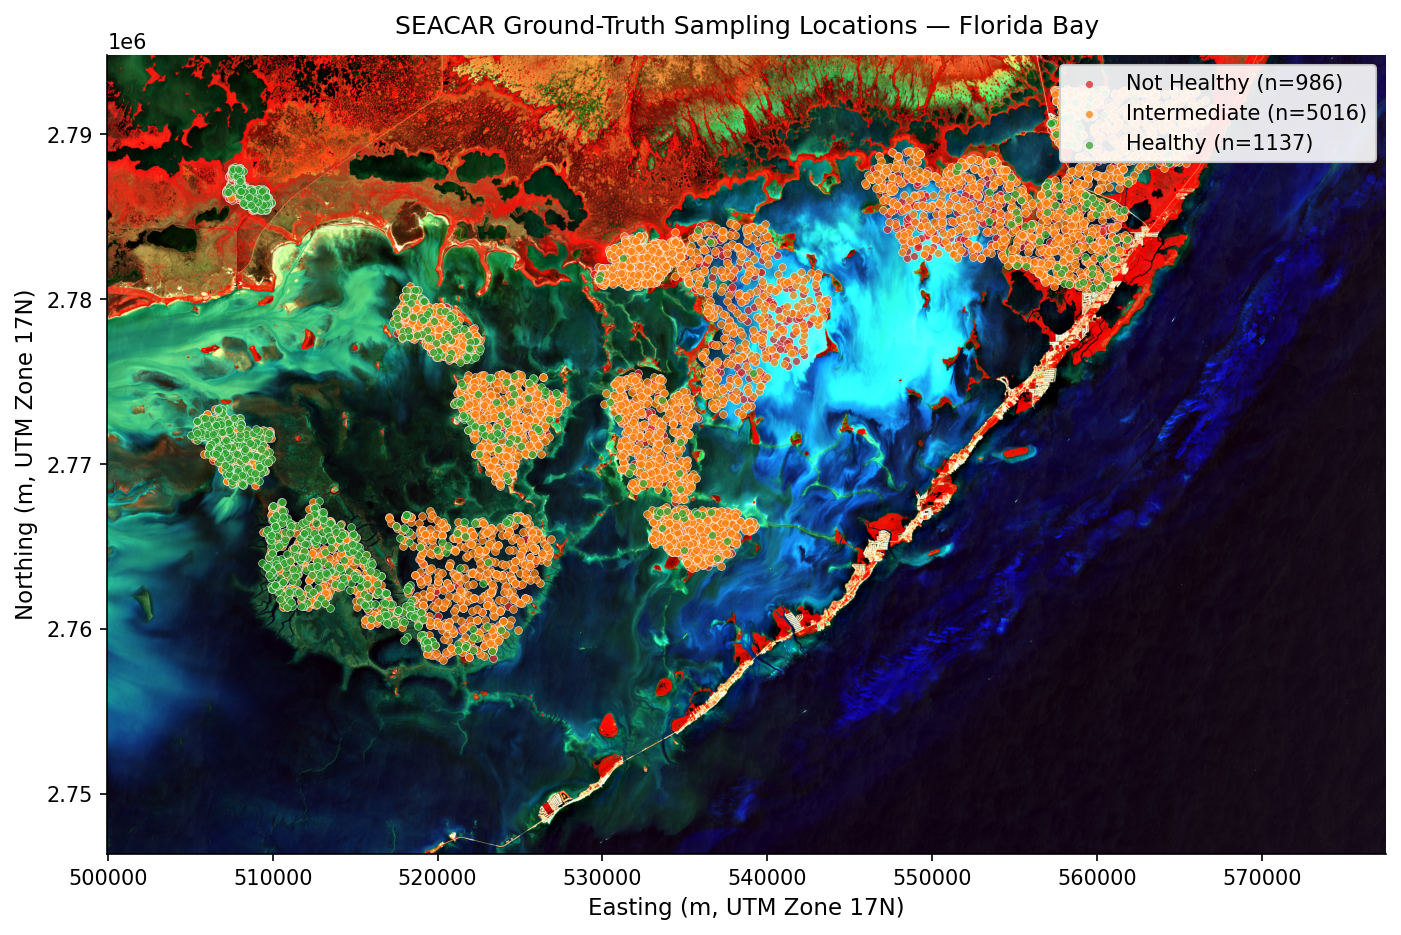

### SEACAR Ground-Truth Sampling Locations (Reference Map)
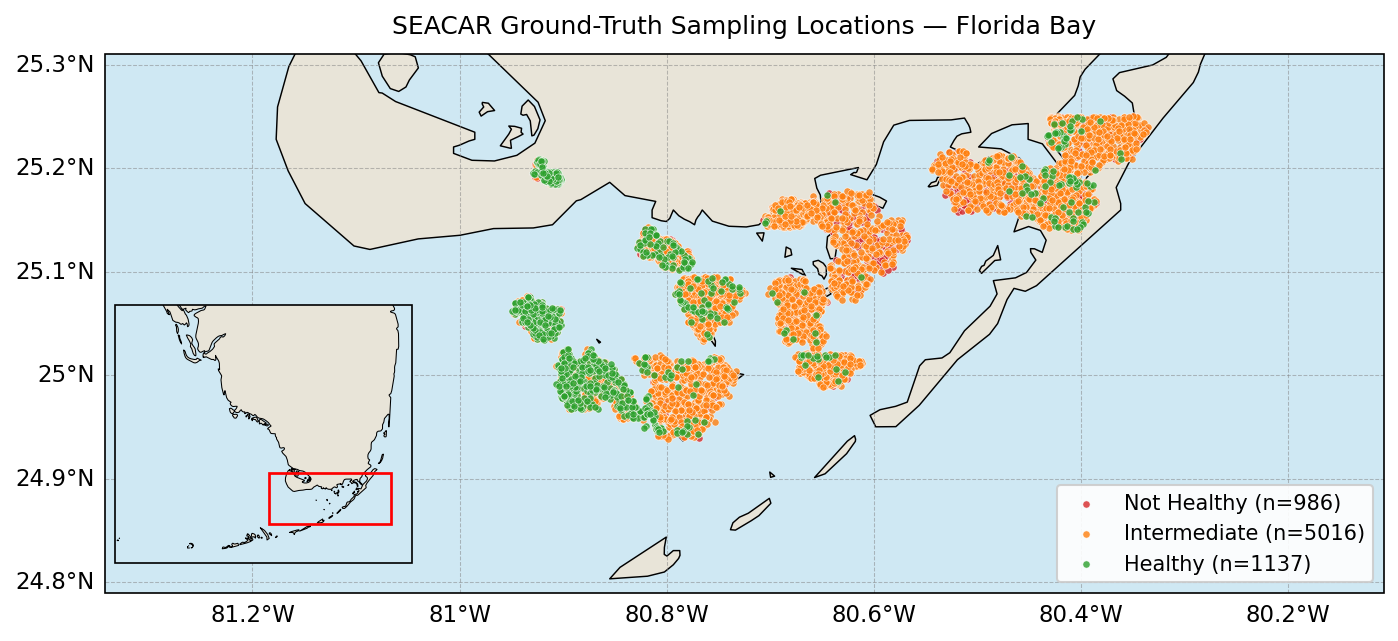

### HABSOS Harmful Algal Bloom Observations (Gulf of Mexico)
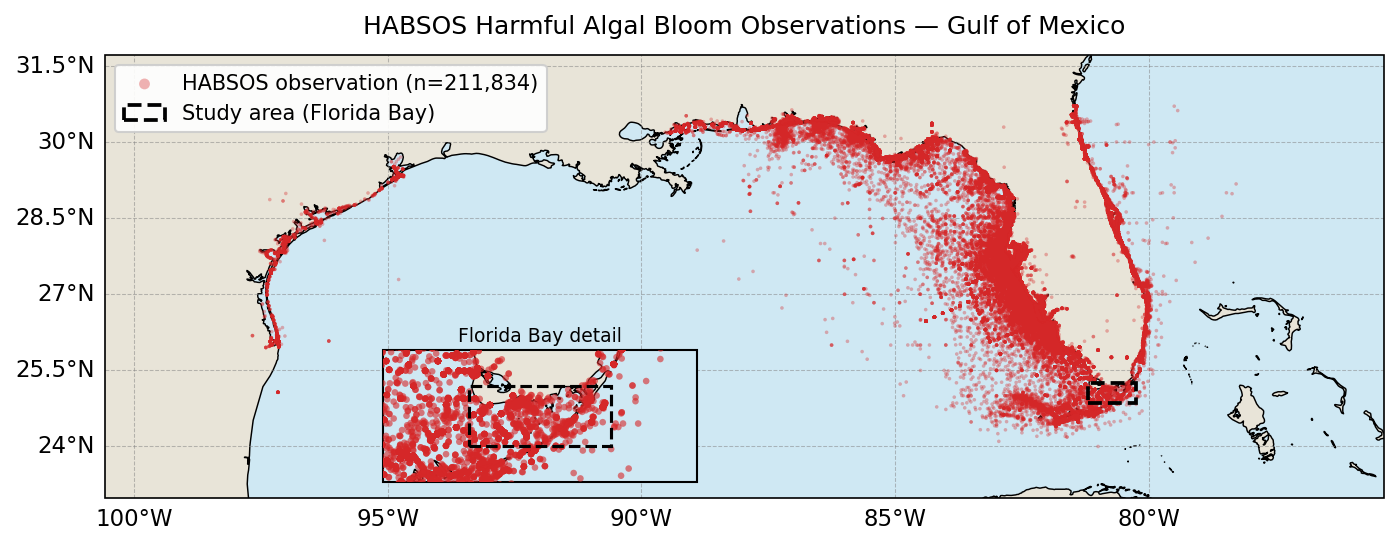
